In [ ]:
!pip install torch_geometric
!pip install torch_cluster -f https://data.pyg.org/whl/torch-2.8.0+cu128.html
!pip install git+https://github.com/tum-pbs/dgn4cfd.git

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms
import torch_geometric
from torch_geometric.nn import MessagePassing
from torch_geometric.transforms import RemoveDuplicatedEdges
from torch_geometric.utils import to_torch_coo_tensor
import dgn4cfd as dgn
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In this notebook we train neural networks to predict the pressure on the wall of an elliptic cylinder that is placed in a two dimensional laminar flow.  We will train an MLP and a GNN for this task.

The data given is not a graph but rather points on the ellipse.  We use the transform `MeshEllipse` given in the package `dgn4cfd` to first connect the points to their neighbours and define a class `ExtendConnectivity` to extend edges to points that are two hops apart.  We apply this twice.

In [5]:
class ExtendConnectivity:
    def __call__(self, data):
        edge_index = data.edge_index
        edge_coo = to_torch_coo_tensor(edge_index)
        two_hop = torch.sparse.mm(edge_coo, edge_coo).indices()
        data.edge_index = torch.cat([edge_index, two_hop], dim=1)
        data.edge_attr = data.pos[data.edge_index[1]] - data.pos[data.edge_index[0]]
        return data

transform = transforms.Compose([
    dgn.transforms.MeshEllipse(),
    ExtendConnectivity(),
    RemoveDuplicatedEdges(reduce="max"),
    ExtendConnectivity(),
    RemoveDuplicatedEdges(reduce="max"),
])


Our dataset contains the two dimensional coordinates of the points on the ellipse, the points' distances to the upper and lower wall, the Reynolds number of the flow and the five most recent pressure values on the points.  Our test dataset have the same distribution Reynolds number and relative thickness as the training dataset.  The datasets are loaded from the package `dgn4cfd`.

In [6]:
batch_size = 16

dataset = dgn.datasets.pOnEllipse(
    path=dgn.datasets.DatasetDownloader(dgn.datasets.DatasetUrl.pOnEllipseTrain).file_path,
    T=60,
    transform=transform,
    preload=False,
)
dataset.training_info['n_in'] = 6
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])
train_dataloader = dgn.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = dgn.DataLoader(dataset=val_dataset, batch_size = batch_size, shuffle=False)

test_dataset = dgn.datasets.pOnEllipse(
    path=dgn.datasets.DatasetDownloader(dgn.datasets.DatasetUrl.pOnEllipseInDist).file_path,
    T=100,
    transform=transform,
    preload=False,
)
test_dataset.training_info['n_in'] = 35
test_dataloader = dgn.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Dataset already exists.
Dataset already exists.


We visualize the first datum from the dataset and the connectivity of the resulting graph.

In [8]:
print(dataset[0])

Graph(pos=[60, 2], glob=[60, 1], loc=[60, 2], target=[60, 6], edge_index=[2, 540], edge_attr=[540, 2])


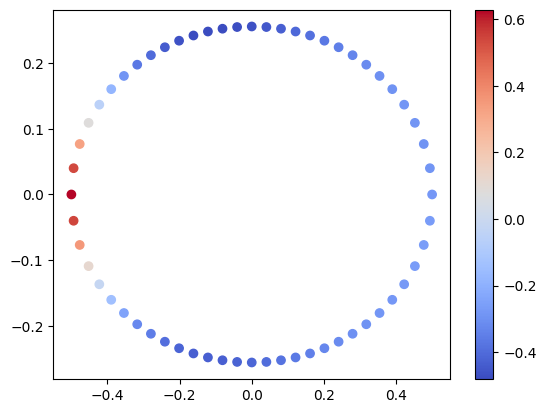

In [36]:
d = dataset[0]
plt.scatter(d.pos[:,0], d.pos[:,1], c=d.target[:,-1], cmap='coolwarm')
plt.colorbar()
plt.show()

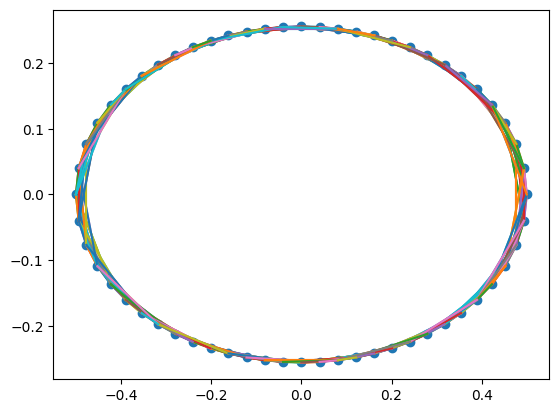

In [10]:
plt.scatter(dataset[0].pos[:, 0], dataset[0].pos[:, 1])
xx = [dataset[0].pos[dataset[0].edge_index[0]][:, 0], dataset[0].pos[dataset[0].edge_index[1]][:, 0]]
yy = [dataset[0].pos[dataset[0].edge_index[0]][:, 1], dataset[0].pos[dataset[0].edge_index[1]][:, 1]]
plt.plot(xx, yy)
plt.show()

We first define the message passing layer of the GNN.  The message passing scheme follows [this paper](https://arxiv.org/abs/1806.01261) with edge updates being the message.  Our data input for GNN has node features the Reynolds number, the distances to the upper and lower wall and the five most recent pressure values.  The edge attributes are given by the relative positions of the nodes.

In [11]:
class MPLayer(MessagePassing):
    def __init__(self):
        super().__init__(aggr="mean")
        self.edge_mlp = nn.Sequential(
            nn.LayerNorm(128 * 3),
            nn.Linear(128 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )
        self.node_mlp = nn.Sequential(
            nn.LayerNorm(128 * 2),
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128)
        )
        self.edge_weight = nn.Linear(128, 128, bias=False)
        self.node_weight = nn.Linear(128, 128, bias=False)

    def forward(self, tup):  # tup = (x, edge_index, edge_attr)
        edge_attr = self.edge_updater(tup[1], edge_attr=tup[2], x=tup[0])
        x = self.propagate(tup[1], edge_attr=edge_attr, x=tup[0])

        return x, tup[1], edge_attr

    def edge_update(self, edge_attr, x_j, x_i):
        return self.edge_weight(edge_attr) + self.edge_mlp(torch.cat([edge_attr, x_j, x_i], dim=1))

    def message(self, edge_attr):
        return edge_attr

    def update(self, inputs, x):
        return self.node_weight(x) + self.node_mlp(torch.cat([inputs, x], dim=1))


In [12]:
class GNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.node_encoder = nn.Linear(8, 128)
        self.edge_encoder = nn.Linear(2, 128)
        mp_layers = []
        for _ in range(8):
            mp_layers.append(MPLayer())
        self.mp = nn.Sequential(*mp_layers)
        self.node_decoder = nn.Linear(128, 1)

    def forward(self, data, unrolling=False):
        data.x = torch.cat([data.glob, data.loc, data.target[:, :5]], dim=1)
        x = self.node_encoder(data.x)
        edge_attr = self.edge_encoder(data.edge_attr)
        x, _, _ = self.mp((x, data.edge_index, edge_attr))
        x = self.node_decoder(x)

        if unrolling:
            return torch.cat([data.target[:, 1:5], x, data.target[:, 6:]], dim=1)
        else:
            return x


Our features for MLP are the coordinates of the nodes as well as the node features for the GNN.

In [13]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(10, 128)
        hidden_layers = []
        for _ in range(8):
            hidden_layers.append(nn.ReLU())
            hidden_layers.append(nn.Linear(128, 128))
        hidden_layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*hidden_layers)
        self.decoder = nn.Linear(128, 1)

    def forward(self, data, unrolling=False):
        x = torch.cat([data.pos, data.glob, data.loc, data.target[:, :5]], dim=1)
        x = self.encoder(x)
        x = self.hidden_layers(x)
        x = self.decoder(x)

        if unrolling:
            return torch.cat([data.target[:, 1:5], x, data.target[:, 6:]], dim=1)
        else:
            return x


We train both models with MSE loss, using Adam optimizer with learning rate $10^{-4}$, a `ReduceLROnPlateau` scheduler with $\text{factor} = 0.1$ and $\text{patience} = 50$ and the training stops once the learning rate drops below $10^{-6}$.

We also test both models by unrolling them $30$ times and visualize the predicted pressure as well as the ground truth.  We also plot the predicted pressure against the ground truth as well as the MSE during rollout.

In [209]:
def validate(model, dataloader):
    model.eval()

    total_num = 0
    total_loss = 0

    with torch.no_grad():
        for data in dataloader:
            y = data.target[:, -1][:, None]
            total_loss += torch.sum((model(data) - y) ** 2).item()
            total_num += data.num_nodes

    return total_loss / total_num

def train(model, train_loader, val_loader, num_epochs):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=50)
    loss_fn = nn.MSELoss()
    tqdm_epochs = tqdm(range(num_epochs))
    avg_loss = []

    model = model.to(device)

    for epoch in tqdm_epochs:

        model.train()

        if scheduler.get_last_lr()[0] < 5e-7:
            print(f"Training complete in epoch {epoch + 1}")
            break

        total_num = 0
        total_loss = 0

        for data in train_loader:

            data = data.to(device)

            optimizer.zero_grad()

            loss = loss_fn(model(data), data.target[:, -1][:, None])
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

            optimizer.step()

            total_loss += loss.detach().item() * data.num_nodes
            total_num += data.num_nodes

        avg_loss.append(total_loss / total_num)
        tqdm_epochs.set_description(f'Average loss: {total_loss / total_num}, lr: {scheduler.get_last_lr()[0]}')
        val_loss = validate(model, val_loader)
        scheduler.step(val_loss)

    print("Training complete")

def test_plot(model_1, model_2, data, sample_type):

    loss = [[], []]
    with torch.no_grad():
        data = data.to(device)
        data_2 = data.detach().clone()
        data_l = [data, data_2]
        for idx, model in enumerate([model_1, model_2]):
            model.eval()
            for i in range(30):
                y = data_l[idx].target[:, 5]
                data_l[idx].target = model(data_l[idx], unrolling=True)
                loss[idx].append(torch.mean((data_l[idx].target[:, 4] - y) ** 2).item())

    fig = plt.figure(figsize=(12,8))
    ax1 = fig.add_subplot(2,3,1)
    ax2 = fig.add_subplot(2,3,2)
    ax3 = fig.add_subplot(2,3,3)
    ax4 = fig.add_subplot(2,3,4)
    ax5 = fig.add_subplot(2,3,5)
    ax6 = fig.add_subplot(2,3,6)
    ax1.scatter(data_l[0].pos[:, 0].cpu(), data_l[0].pos[:, 1].cpu(), c=data_l[0].target[:, 4].cpu(), cmap='coolwarm',
               vmin=min(data_l[0].target[:, 4].cpu().min(), data_l[1].target[:, 4].cpu().min(), y.cpu().min()),
               vmax=max(data_l[0].target[:, 4].cpu().max(), data_l[1].target[:, 4].cpu().max(), y.cpu().max()))
    ax1.set_title(f"Predicted pressure of {model_1.__class__.__name__}")
    ax2.scatter(data_l[0].pos[:, 0].cpu(), data_l[0].pos[:, 1].cpu(), c=data_l[1].target[:, 4].cpu(), cmap='coolwarm',
               vmin=min(data_l[0].target[:, 4].cpu().min(), data_l[1].target[:, 4].cpu().min(), y.cpu().min()),
               vmax=max(data_l[0].target[:, 4].cpu().max(), data_l[1].target[:, 4].cpu().max(), y.cpu().max()))
    ax2.set_title(f"Predicted pressure of {model_2.__class__.__name__}")
    ax3.scatter(data_l[0].pos[:, 0].cpu(), data_l[0].pos[:, 1].cpu(), c=y.cpu(), cmap='coolwarm',
               vmin=min(data_l[0].target[:, 4].cpu().min(), data_l[1].target[:, 4].cpu().min(), y.cpu().min()),
               vmax=max(data_l[0].target[:, 4].cpu().max(), data_l[1].target[:, 4].cpu().max(), y.cpu().max()))
    ax3.set_title("Ground truth")
    ax4.scatter(y.cpu(), data_l[0].target[:, 4].cpu())
    ax4.set_title(f"Prediction of {model_1.__class__.__name__} against GT")
    ax5.scatter(y.cpu(), data_l[1].target[:, 4].cpu())
    ax5.set_title(f"Prediction of {model_2.__class__.__name__} against GT")
    ax6.plot(range(1, 31), loss[0], label=f'{model_1.__class__.__name__}')
    ax6.plot(range(1, 31), loss[1], label=f'{model_2.__class__.__name__}')
    ax6.legend()
    ax6.set_title("MSE during rollout")
    fig.suptitle(f"Sample: {sample_type}")
    plt.show()


In [20]:
mlp = MLP()
gnn = GNN()

In [21]:
train(mlp, train_dataloader, val_dataloader, 5000)

Average loss: 0.0001718102373197571, lr: 1.0000000000000002e-06:  12%| | 599/500

Training complete in epoch 600
Training complete


In [22]:
train(gnn, train_dataloader, val_dataloader, 5000)

Average loss: 5.473236223771217e-05, lr: 1.0000000000000002e-06:  14%|▏| 714/500

Training complete in epoch 715
Training complete


We see that the GNN performs better than MLP in the test dataset which has in distribution Reynold numbers and relative thickness.

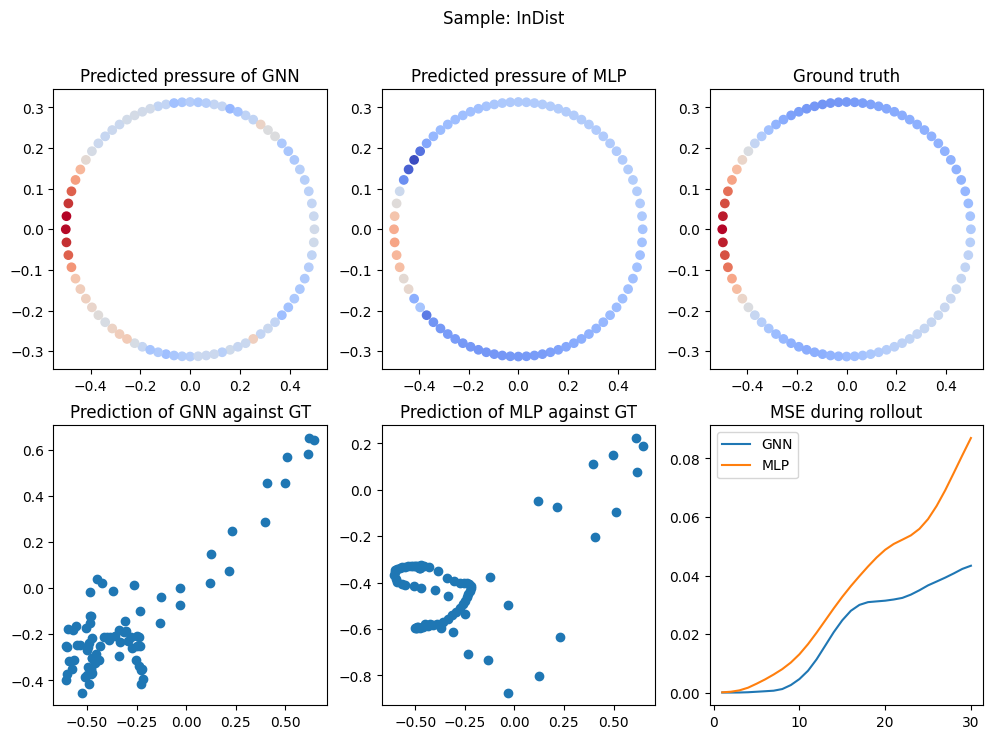

In [229]:
test_plot(gnn, mlp, test_dataset[9], "InDist")

In [44]:
lowre_dataset = dgn.datasets.pOnEllipse(
    path=dgn.datasets.DatasetDownloader(dgn.datasets.DatasetUrl.pOnEllipseLowRe).file_path,
    T=100,
    transform=transform,
    preload=False,
)
lowre_dataset.training_info['n_in'] = 35
highre_dataset = dgn.datasets.pOnEllipse(
    path=dgn.datasets.DatasetDownloader(dgn.datasets.DatasetUrl.pOnEllipseHighRe).file_path,
    T=100,
    transform=transform,
    preload=False,
)
highre_dataset.training_info['n_in'] = 35

Dataset already exists.
Dataset already exists.


We can also see that GNN generalizes better than MLP when encountering samples with out of distribution Reynolds numbers, results with low Re and high Re are shown below.

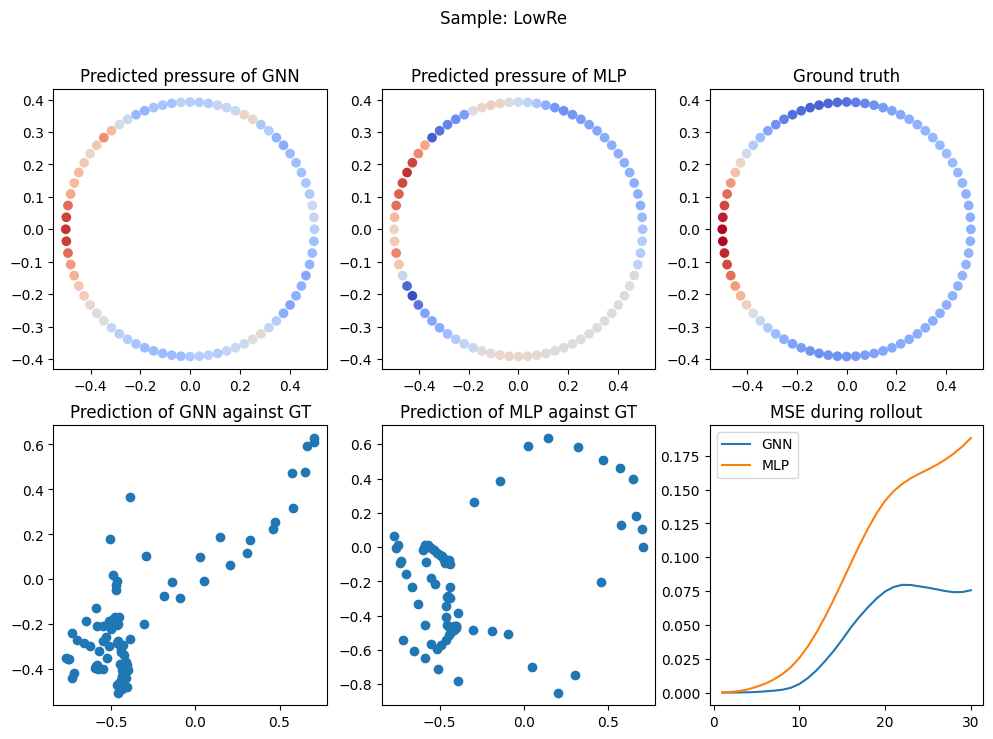

In [213]:
test_plot(gnn, mlp, lowre_dataset[9], "LowRe")

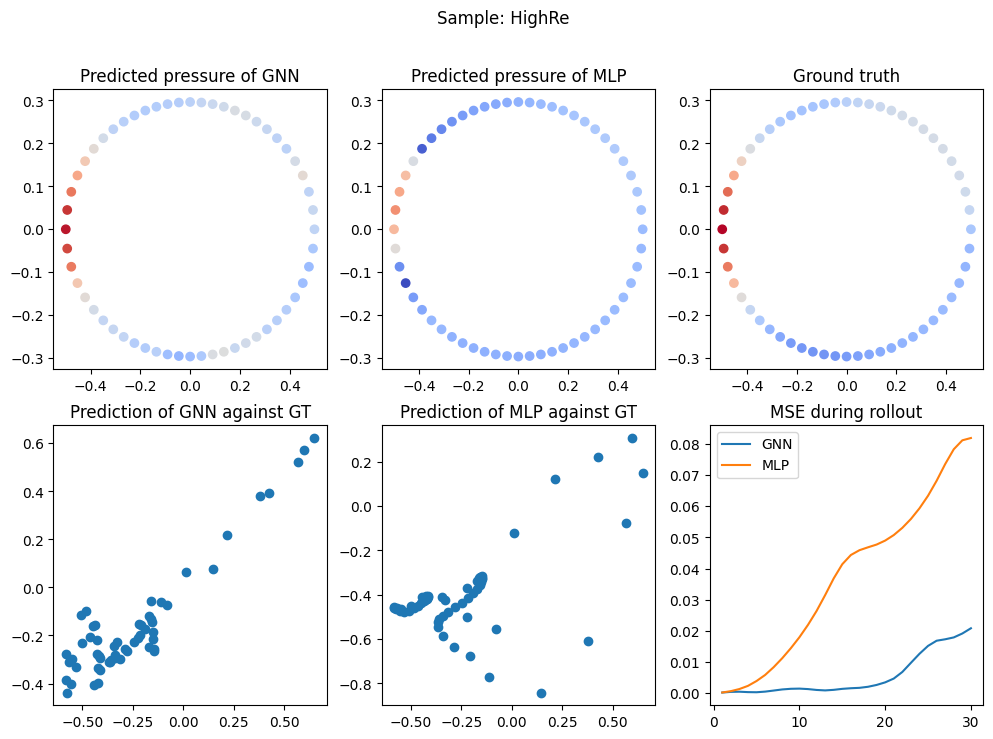

In [220]:
test_plot(gnn, mlp, highre_dataset[9], "HighRe")